# Exploración de los datos de T02

## Objetivo

Este cuaderno estudia los registros de acelerometría y las etiquetas de
comportamiento correspondientes a T02.

Los objetivos son:

1. cargar los archivos de acelerometría y etiquetas;
2. comprobar su estructura e integridad;
3. alinear ambas fuentes mediante sus identificadores originales;
4. localizar los segmentos etiquetados como baño de arena;
5. visualizar la señal desde 5 segundos antes hasta 30 segundos después
   del comienzo de cada etiqueta.

La frecuencia de muestreo utilizada es:

$f_s = 25\ \text{Hz}$

por lo que cada muestra representa $0.040\ \text{s}$.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FS = 25

plt.style.use("seaborn-v0_8-whitegrid")

## 1. Localización de los archivos

Los datos descomprimidos de T02 se encuentran dentro de `data_raw/T02`.
Primero se comprueba que la carpeta exista para evitar errores posteriores
durante la lectura de los archivos.

In [2]:
carpeta_t02 = Path(
    "/Users/josi/Trabajo_Especial/"
    "Bases_de_datos_codornices/"
    "data_raw/T02"
)

print("Carpeta:", carpeta_t02)
print("Existe:", carpeta_t02.exists())

Carpeta: /Users/josi/Trabajo_Especial/Bases_de_datos_codornices/data_raw/T02
Existe: True


## 2. Identificación de los archivos

T02 contiene dos archivos de acelerometría y un archivo de etiquetas.

Los archivos que contienen `sincomportamiento` corresponden a las mediciones
del acelerómetro. El archivo restante que contiene `comportamientos`
corresponde a las etiquetas observadas.

In [3]:
archivos_csv = sorted(
    carpeta_t02.glob("*.csv")
)

for archivo in archivos_csv:
    print(archivo.name)

T02_sincomportamiento_1.csv
T02_sincomportamiento_2.csv
T2_comportamientos.csv


In [4]:
rutas_acelerometria = sorted([
    archivo
    for archivo in archivos_csv
    if "sincomportamiento" in archivo.name.lower()
])

rutas_etiquetas = [
    archivo
    for archivo in archivos_csv
    if "comportamientos" in archivo.name.lower()
    and "sincomportamiento" not in archivo.name.lower()
]

print("Acelerometría:")

for archivo in rutas_acelerometria:
    print("-", archivo.name)

print("\nEtiquetas:")

for archivo in rutas_etiquetas:
    print("-", archivo.name)

Acelerometría:
- T02_sincomportamiento_1.csv
- T02_sincomportamiento_2.csv

Etiquetas:
- T2_comportamientos.csv


## 3. Carga y concatenación de la acelerometría

Las dos partes de acelerometría se cargan por separado y luego se concatenan
en el orden determinado por sus nombres.

Las etiquetas se cargan de manera independiente porque posteriormente será
necesario verificar si sus identificadores coinciden con los de la
acelerometría.

In [5]:
partes_acelerometria = [
    pd.read_csv(archivo, index_col=0)
    for archivo in rutas_acelerometria
]

acelerometria_t02 = pd.concat(
    partes_acelerometria,
    ignore_index=True
)

etiquetas_t02 = pd.read_csv(
    rutas_etiquetas[0],
    index_col=0
).reset_index(drop=True)

print(
    "Acelerometría:",
    acelerometria_t02.shape
)

print(
    "Etiquetas:",
    etiquetas_t02.shape
)

Acelerometría: (939000, 12)
Etiquetas: (939001, 5)


## 4. Diagnóstico de la correspondencia entre las bases

Antes de combinar la acelerometría con las etiquetas, se comprueba:

- la cantidad de filas de cada archivo;
- el rango de identificadores;
- la existencia de identificadores repetidos;
- la existencia de muestras presentes solamente en una de las bases.

Estas verificaciones son necesarias porque ambas fuentes no contienen
exactamente las mismas muestras.

In [6]:
print("Tamaño de cada parte:")

for numero, parte in enumerate(
    partes_acelerometria,
    start=1
):
    print(
        f"Parte {numero}:",
        parte.shape
    )

    display(
        parte[
            ["Unnamed: 0", "Time"]
        ].head(3)
    )

    display(
        parte[
            ["Unnamed: 0", "Time"]
        ].tail(3)
    )

Tamaño de cada parte:
Parte 1: (469500, 12)


,Unnamed: 0,Time
0,172,09:26:36.880
1,173,09:26:36.920
2,174,09:26:36.960


,Unnamed: 0,Time
469497,469669,14:39:36.760
469498,469670,14:39:36.800
469499,469671,14:39:36.840


Parte 2: (469500, 12)


,Unnamed: 0,Time
469501,469673,14:39:36.920
469502,469674,14:39:36.960
469503,469675,14:39:37.000


,Unnamed: 0,Time
938998,939170,19:52:36.800
938999,939171,19:52:36.840
939000,939172,19:52:36.880


In [7]:
etiquetas_originales = pd.read_csv(
    rutas_etiquetas[0],
    index_col=0
)

print(
    "Primer índice de etiquetas:",
    etiquetas_originales.index[0]
)

print(
    "Último índice de etiquetas:",
    etiquetas_originales.index[-1]
)

display(etiquetas_originales.head(3))
display(etiquetas_originales.tail(3))

Primer índice de etiquetas: 0
Último índice de etiquetas: 939000


,Otros,Reproductivo,Sacudida,Higiene,Baño de arena
0,1.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0


,Otros,Reproductivo,Sacudida,Higiene,Baño de arena
938998,1.0,0.0,0.0,0.0,0.0
938999,1.0,0.0,0.0,0.0,0.0
939000,1.0,0.0,0.0,0.0,0.0


In [8]:
display(
    acelerometria_t02[
        ["Unnamed: 0", "Time"]
    ].head(5)
)

display(
    acelerometria_t02[
        ["Unnamed: 0", "Time"]
    ].tail(5)
)

,Unnamed: 0,Time
0,172,09:26:36.880
1,173,09:26:36.920
2,174,09:26:36.960
3,175,09:26:37.000
4,176,09:26:37.040


,Unnamed: 0,Time
938995,939168,19:52:36.720
938996,939169,19:52:36.760
938997,939170,19:52:36.800
938998,939171,19:52:36.840
938999,939172,19:52:36.880


In [9]:
print(
    "Índices repetidos en acelerometría:",
    acelerometria_t02["Unnamed: 0"]
    .duplicated()
    .sum()
)

print(
    "Índices repetidos en etiquetas:",
    etiquetas_originales.index
    .duplicated()
    .sum()
)

Índices repetidos en acelerometría: 0
Índices repetidos en etiquetas: 0


In [10]:
indice_acelerometria = pd.Index(
    pd.to_numeric(
        acelerometria_t02["Unnamed: 0"]
    ).astype(int)
)

indice_etiquetas = pd.Index(
    pd.to_numeric(
        etiquetas_originales.index
    ).astype(int)
)

print(
    "Acelerometría:",
    indice_acelerometria.min(),
    "a",
    indice_acelerometria.max()
)

print(
    "Etiquetas:",
    indice_etiquetas.min(),
    "a",
    indice_etiquetas.max()
)

solo_en_acelerometria = (
    indice_acelerometria
    .difference(indice_etiquetas)
)

solo_en_etiquetas = (
    indice_etiquetas
    .difference(indice_acelerometria)
)

print(
    "Índices solamente en acelerometría:",
    solo_en_acelerometria.tolist()
)

print(
    "Índices solamente en etiquetas:",
    solo_en_etiquetas.tolist()
)

Acelerometría: 172 a 939172
Etiquetas: 0 a 939000
Índices solamente en acelerometría: [939001, 939002, 939003, 939004, 939005, 939006, 939007, 939008, 939009, 939010, 939011, 939012, 939013, 939014, 939015, 939016, 939017, 939018, 939019, 939020, 939021, 939022, 939023, 939024, 939025, 939026, 939027, 939028, 939029, 939030, 939031, 939032, 939033, 939034, 939035, 939036, 939037, 939038, 939039, 939040, 939041, 939042, 939043, 939044, 939045, 939046, 939047, 939048, 939049, 939050, 939051, 939052, 939053, 939054, 939055, 939056, 939057, 939058, 939059, 939060, 939061, 939062, 939063, 939064, 939065, 939066, 939067, 939068, 939069, 939070, 939071, 939072, 939073, 939074, 939075, 939076, 939077, 939078, 939079, 939080, 939081, 939082, 939083, 939084, 939085, 939086, 939087, 939088, 939089, 939090, 939091, 939092, 939093, 939094, 939095, 939096, 939097, 939098, 939099, 939100, 939101, 939102, 939103, 939104, 939105, 939106, 939107, 939108, 939109, 939110, 939111, 939112, 939113, 939114, 9

In [11]:
# Eliminar el índice interno del procesamiento
acelerometria_t02_limpia = (
    acelerometria_t02
    .drop(columns=["Unnamed: 0"])
    .reset_index(drop=True)
)

# Conservar solamente las etiquetas que tienen
# una muestra de acelerometría correspondiente
etiquetas_t02_limpias = (
    etiquetas_originales
    .reset_index(drop=True)
    .iloc[:len(acelerometria_t02_limpia)]
    .copy()
)

print(
    "Acelerometría limpia:",
    acelerometria_t02_limpia.shape
)

print(
    "Etiquetas limpias:",
    etiquetas_t02_limpias.shape
)

Acelerometría limpia: (939000, 11)
Etiquetas limpias: (939000, 5)


In [12]:
datos_t02 = pd.concat(
    [
        acelerometria_t02_limpia,
        etiquetas_t02_limpias
    ],
    axis=1
)

print("Base T02:", datos_t02.shape)

display(datos_t02.head())
display(datos_t02.tail())

Base T02: (939000, 16)


,Time,Axis-X,Axis-Y,Axis-Z,time_parsed,DBA-X,DBA-Y,DBA-Z,Pow-X,Pow-Y,Pow-Z,Otros,Reproductivo,Sacudida,Higiene,Baño de arena
0,09:26:36.880,-0.312,0.125,0.969,2022-06-08 09:26:30,-0.30908,0.14036,0.969,1.978801,0.951318,7.796422,1.0,0.0,0.0,0.0,0.0
1,09:26:36.920,-0.297,0.141,0.969,2022-06-08 09:26:30,-0.30908,0.14036,0.969,2.071048,0.911625,7.704664,1.0,0.0,0.0,0.0,0.0
2,09:26:36.960,-0.297,0.141,0.969,2022-06-08 09:26:30,-0.30908,0.14036,0.969,2.079844,0.850924,7.512006,1.0,0.0,0.0,0.0,0.0
3,09:26:37.000,-0.297,0.141,0.969,2022-06-08 09:26:30,-0.30908,0.14036,0.969,2.070664,1.047371,7.532982,1.0,0.0,0.0,0.0,0.0
4,09:26:37.040,-0.312,0.141,0.969,2022-06-08 09:26:30,-0.30908,0.14036,0.969,2.100200,0.753403,7.375566,1.0,0.0,0.0,0.0,0.0


,Time,Axis-X,Axis-Y,Axis-Z,time_parsed,DBA-X,DBA-Y,DBA-Z,Pow-X,Pow-Y,Pow-Z,Otros,Reproductivo,Sacudida,Higiene,Baño de arena
938995,19:52:36.720,0.188,0.0,1.016,2022-06-08 09:26:30,0.18920,-0.00064,1.016,0.912763,0.061253,8.966826,1.0,0.0,0.0,0.0,0.0
938996,19:52:36.760,0.188,0.0,1.016,2022-06-08 09:26:30,0.18920,-0.00064,1.016,0.906212,0.064921,8.967519,1.0,0.0,0.0,0.0,0.0
938997,19:52:36.800,0.188,0.0,1.016,2022-06-08 09:26:30,0.18920,-0.00064,1.016,0.911932,0.059648,9.078783,1.0,0.0,0.0,0.0,0.0
938998,19:52:36.840,0.203,0.0,1.016,2022-06-08 09:26:30,0.18936,0.00000,1.016,0.909399,0.063673,8.946228,1.0,0.0,0.0,0.0,0.0
938999,19:52:36.880,0.188,0.0,1.016,2022-06-08 09:26:30,0.18976,0.00000,1.016,0.922561,0.059106,9.007925,1.0,0.0,0.0,0.0,0.0


## 5. Alineación mediante `sample_id`

El diagnóstico anterior demuestra que la acelerometría y las etiquetas no
pueden combinarse directamente por posición.

Para conservar la correspondencia correcta, se utiliza el identificador
original de cada muestra, denominado `sample_id`.

La unión interna conserva solamente los identificadores presentes tanto en
la acelerometría como en las etiquetas. La base alineada resultante contiene
938 828 muestras.

In [13]:
# Preparar identificadores de acelerometría
acelerometria_alineada = acelerometria_t02.rename(
    columns={"Unnamed: 0": "sample_id"}
).copy()

acelerometria_alineada["sample_id"] = pd.to_numeric(
    acelerometria_alineada["sample_id"]
).astype(int)

# Preparar identificadores de etiquetas
etiquetas_alineadas = etiquetas_originales.copy()

etiquetas_alineadas.index = pd.to_numeric(
    etiquetas_alineadas.index
).astype(int)

etiquetas_alineadas.index.name = "sample_id"

# Unir solamente muestras con el mismo identificador
datos_t02 = (
    acelerometria_alineada
    .set_index("sample_id")
    .join(
        etiquetas_alineadas,
        how="inner",
        validate="one_to_one"
    )
    .sort_index()
)

print("Base T02 alineada:", datos_t02.shape)
print(
    "Rango de identificadores:",
    datos_t02.index.min(),
    "a",
    datos_t02.index.max()
)

display(datos_t02.head())
display(datos_t02.tail())

Base T02 alineada: (938828, 16)
Rango de identificadores: 172 a 939000


,Time,Axis-X,Axis-Y,Axis-Z,time_parsed,DBA-X,DBA-Y,DBA-Z,Pow-X,Pow-Y,Pow-Z,Otros,Reproductivo,Sacudida,Higiene,Baño de arena
sample_id,,,,,,,,,,,,,,,,
172,09:26:36.880,-0.312,0.125,0.969,2022-06-08 09:26:30,-0.30908,0.14036,0.969,1.978801,0.951318,7.796422,1.0,0.0,0.0,0.0,0.0
173,09:26:36.920,-0.297,0.141,0.969,2022-06-08 09:26:30,-0.30908,0.14036,0.969,2.071048,0.911625,7.704664,1.0,0.0,0.0,0.0,0.0
174,09:26:36.960,-0.297,0.141,0.969,2022-06-08 09:26:30,-0.30908,0.14036,0.969,2.079844,0.850924,7.512006,1.0,0.0,0.0,0.0,0.0
175,09:26:37.000,-0.297,0.141,0.969,2022-06-08 09:26:30,-0.30908,0.14036,0.969,2.070664,1.047371,7.532982,1.0,0.0,0.0,0.0,0.0
176,09:26:37.040,-0.312,0.141,0.969,2022-06-08 09:26:30,-0.30908,0.14036,0.969,2.100200,0.753403,7.375566,1.0,0.0,0.0,0.0,0.0


,Time,Axis-X,Axis-Y,Axis-Z,time_parsed,DBA-X,DBA-Y,DBA-Z,Pow-X,Pow-Y,Pow-Z,Otros,Reproductivo,Sacudida,Higiene,Baño de arena
sample_id,,,,,,,,,,,,,,,,
938996,19:52:29.840,0.188,0.000,1.016,2022-06-08 09:26:30,0.188,-0.01104,1.0154,1.024446,0.077252,9.000748,1.0,0.0,0.0,0.0,0.0
938997,19:52:29.880,0.188,-0.014,1.016,2022-06-08 09:26:30,0.188,-0.01104,1.0154,1.016170,0.084146,8.890182,1.0,0.0,0.0,0.0,0.0
938998,19:52:29.920,0.188,-0.001,1.016,2022-06-08 09:26:30,0.188,-0.01104,1.0154,1.013612,0.071519,8.916034,1.0,0.0,0.0,0.0,0.0
938999,19:52:29.960,0.188,-0.016,1.016,2022-06-08 09:26:30,0.188,-0.01104,1.0154,1.004395,0.078264,9.005880,1.0,0.0,0.0,0.0,0.0
939000,19:52:30.000,0.188,0.000,1.016,2022-06-08 09:26:30,0.188,-0.01104,1.0154,1.051694,0.066598,9.015885,1.0,0.0,0.0,0.0,0.0


## 6. Identificación de segmentos de baño de arena

Un segmento se define como una sucesión de muestras consecutivas en las que
la columna `Baño de arena` vale 1.

También se inicia un nuevo segmento cuando aparece un salto en los
identificadores, porque dicho salto indica que falta al menos una muestra.

Como la frecuencia de muestreo es de 25 Hz, la duración de un segmento se
calcula mediante:

$$
\text{duración} =
\frac{\text{cantidad de muestras}}{25}.
$$

In [14]:
datos_t02["time_seconds"] = (
    pd.to_timedelta(datos_t02["Time"])
    .dt.total_seconds()
)

def extraer_segmentos(df, etiqueta):
    tabla = df.reset_index()

    activa = tabla[etiqueta].eq(1)

    # También separa segmentos si falta alguna muestra
    continuidad = tabla["sample_id"].diff().eq(1)

    comienzo = (
        activa
        & (
            ~activa.shift(fill_value=False)
            | ~continuidad
        )
    )

    tabla["segmento"] = comienzo.cumsum()

    segmentos = (
        tabla.loc[activa]
        .groupby("segmento", as_index=False)
        .agg(
            sample_id_inicio=("sample_id", "first"),
            sample_id_fin=("sample_id", "last"),
            t_inicio=("time_seconds", "first"),
            t_fin=("time_seconds", "last"),
            muestras=("sample_id", "size")
        )
    )

    segmentos["duracion_etiqueta_s"] = (
        segmentos["t_fin"]
        - segmentos["t_inicio"]
        + 1 / FS
    )

    return segmentos

In [15]:
segmentos_bano = extraer_segmentos(
    datos_t02,
    "Baño de arena"
)

display(segmentos_bano)

,segmento,sample_id_inicio,sample_id_fin,t_inicio,t_fin,muestras,duracion_etiqueta_s
0,1,152225,152249,40079.0,40079.96,25,1.0
1,2,289175,289199,45557.0,45557.96,25,1.0
2,3,332500,332524,47290.0,47290.96,25,1.0
3,4,339650,339674,47576.0,47576.96,25,1.0
4,5,345075,345099,47793.0,47793.96,25,1.0
5,6,401775,401799,50061.0,50061.96,25,1.0
6,7,848250,848274,67920.0,67920.96,25,1.0
7,8,883275,883324,69321.0,69322.96,50,2.0
8,9,907475,907499,70289.0,70289.96,25,1.0


### Resultado de la segmentación

Se identificaron nueve segmentos etiquetados como baño de arena:

- ocho segmentos contienen 25 muestras, equivalentes a 1 segundo;
- un segmento contiene 50 muestras, equivalentes a 2 segundos.

Estas duraciones son menores que los 20–30 segundos esperados para un baño
completo. Por lo tanto, es posible que la etiqueta señale solamente el
comienzo del comportamiento.

## 7. Visualización temporal de los eventos

Cada evento se representa desde 5 segundos antes hasta 30 segundos después
del comienzo de la etiqueta.

En cada gráfico:

- la línea roja discontinua señala el comienzo de la etiqueta;
- la región roja sombreada representa el intervalo etiquetado;
- el resto de la ventana permite estudiar la actividad posterior;
- los ejes X, Y y Z se muestran por separado.

El objetivo es buscar oscilaciones repetitivas y posibles movimientos
alternados entre ejes.

In [16]:
def graficar_evento(
    df,
    segmentos,
    numero=0,
    segundos_antes=5,
    segundos_despues=30
):
    evento = segmentos.iloc[numero]

    t_inicio = evento["t_inicio"]
    duracion_etiqueta = evento["duracion_etiqueta_s"]

    ventana = df[
        df["time_seconds"].between(
            t_inicio - segundos_antes,
            t_inicio + segundos_despues
        )
    ].copy()

    tiempo_relativo = (
        ventana["time_seconds"] - t_inicio
    )

    columnas = ["Axis-X", "Axis-Y", "Axis-Z"]
    colores = ["tab:blue", "tab:orange", "tab:green"]

    fig, ejes = plt.subplots(
        3,
        1,
        figsize=(14, 9),
        sharex=True
    )

    for eje, columna, color in zip(
        ejes,
        columnas,
        colores
    ):
        eje.plot(
            tiempo_relativo,
            ventana[columna],
            color=color,
            linewidth=1
        )

        # Comienzo de la etiqueta
        eje.axvline(
            0,
            color="red",
            linestyle="--",
            label="Inicio de etiqueta"
        )

        # Intervalo realmente etiquetado
        eje.axvspan(
            0,
            duracion_etiqueta,
            color="red",
            alpha=0.15
        )

        eje.set_ylabel(columna)

    ejes[0].legend()
    ejes[-1].set_xlabel(
        "Tiempo desde el inicio de la etiqueta (s)"
    )

    fig.suptitle(
        f"Baño de arena — segmento {numero + 1}\n"
        f"Duración etiquetada: "
        f"{duracion_etiqueta:.2f} s"
    )

    plt.tight_layout()
    plt.show()

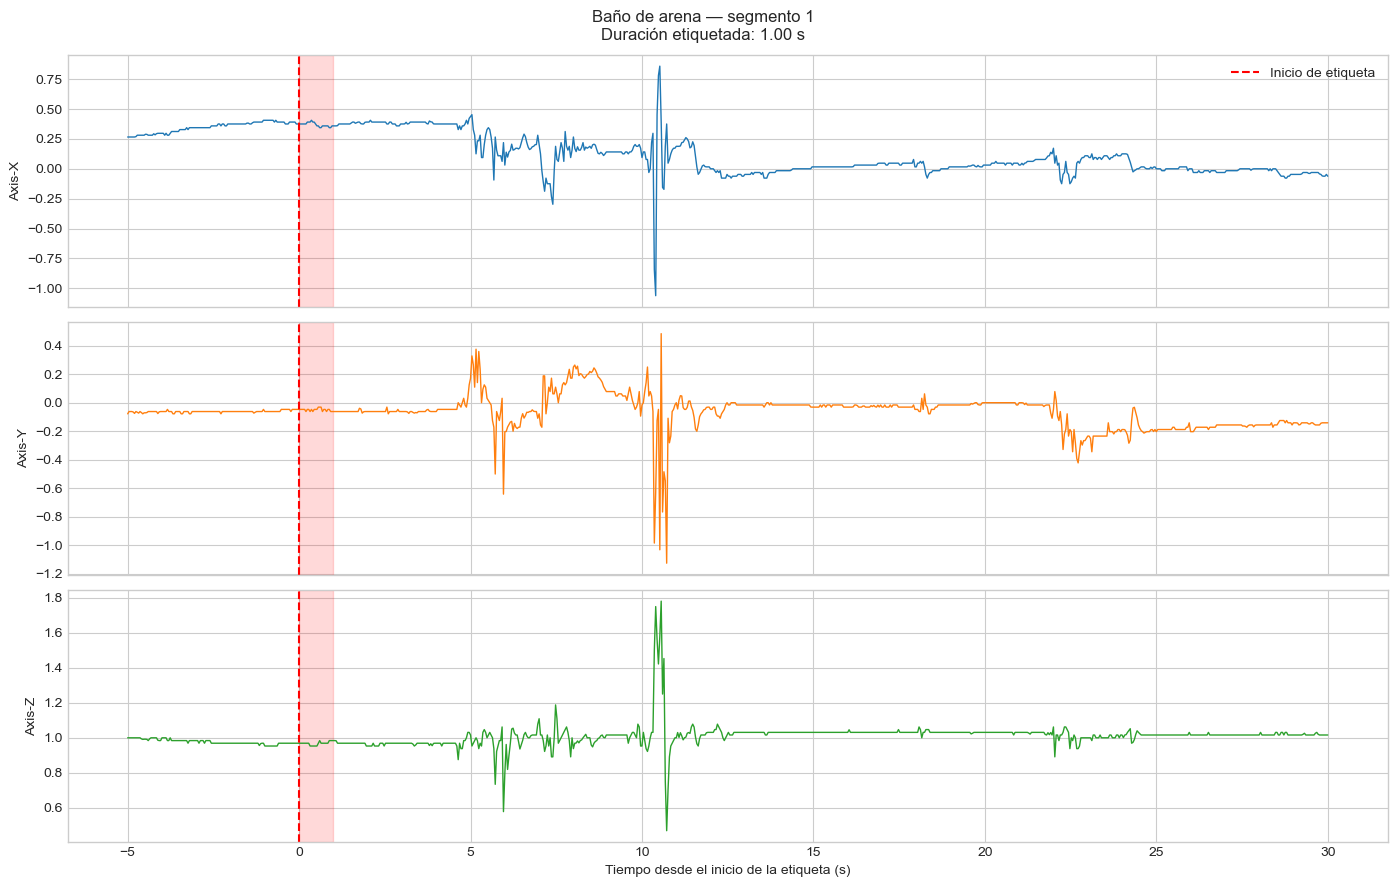

In [17]:
graficar_evento(
    datos_t02,
    segmentos_bano,
    numero=0
)

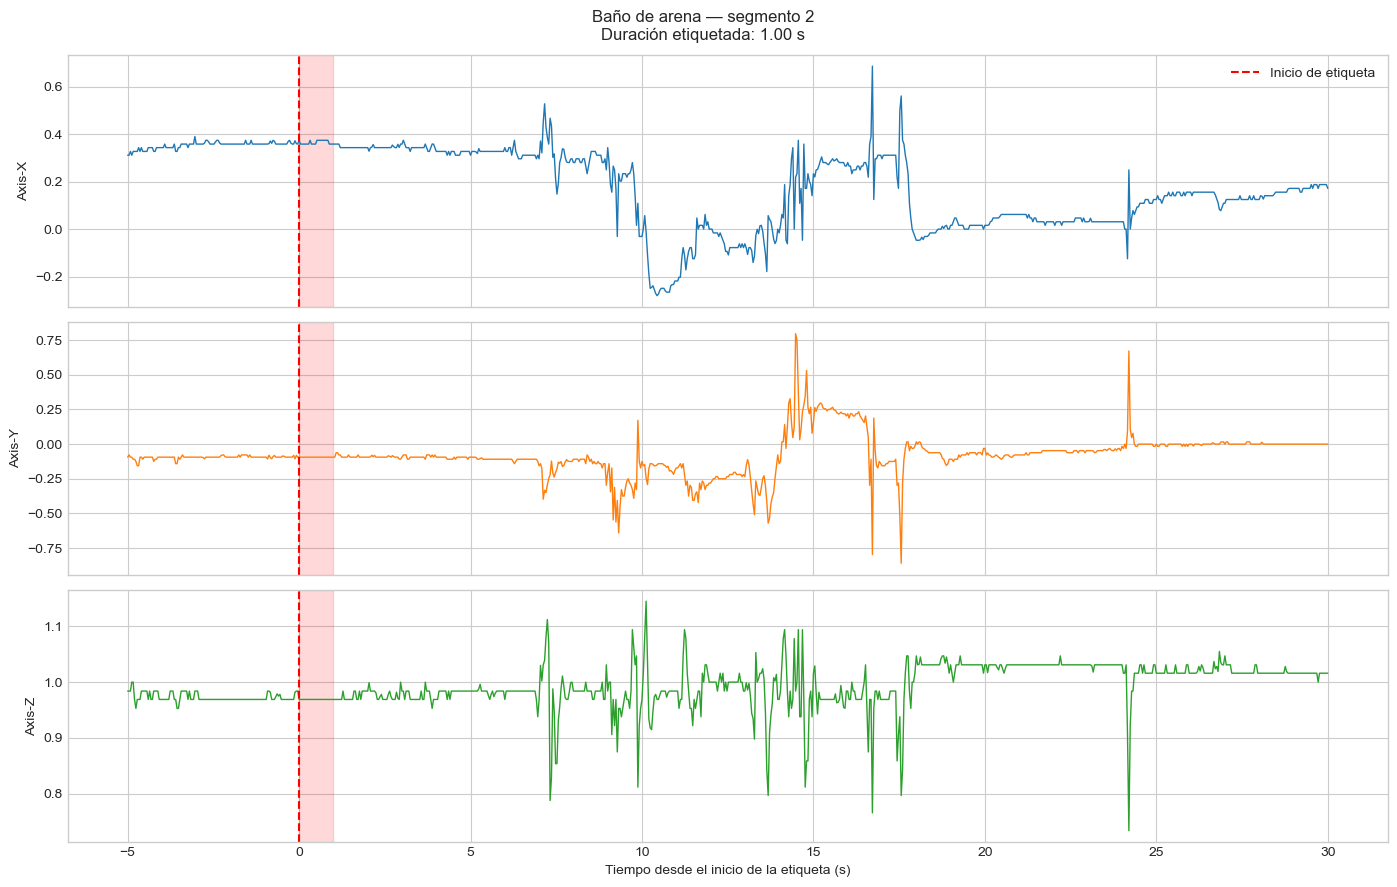

In [18]:
graficar_evento(
    datos_t02,
    segmentos_bano,
    numero=1
)

## 8. Selección de eventos para inspección visual

Los segmentos se ordenan inicialmente según la duración de su etiqueta.

Esta duración no representa necesariamente la duración real del baño. El
ordenamiento solamente permite comenzar la inspección con la etiqueta más
larga y luego comparar visualmente varios eventos.

In [19]:
segmentos_bano_ordenados = (
    segmentos_bano
    .sort_values(
        "duracion_etiqueta_s",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    segmentos_bano_ordenados[
        [
            "sample_id_inicio",
            "sample_id_fin",
            "muestras",
            "duracion_etiqueta_s"
        ]
    ].head(10)
)

,sample_id_inicio,sample_id_fin,muestras,duracion_etiqueta_s
0,883275,883324,50,2.0
1,848250,848274,25,1.0
2,907475,907499,25,1.0
3,152225,152249,25,1.0
4,289175,289199,25,1.0
5,332500,332524,25,1.0
6,339650,339674,25,1.0
7,345075,345099,25,1.0
8,401775,401799,25,1.0


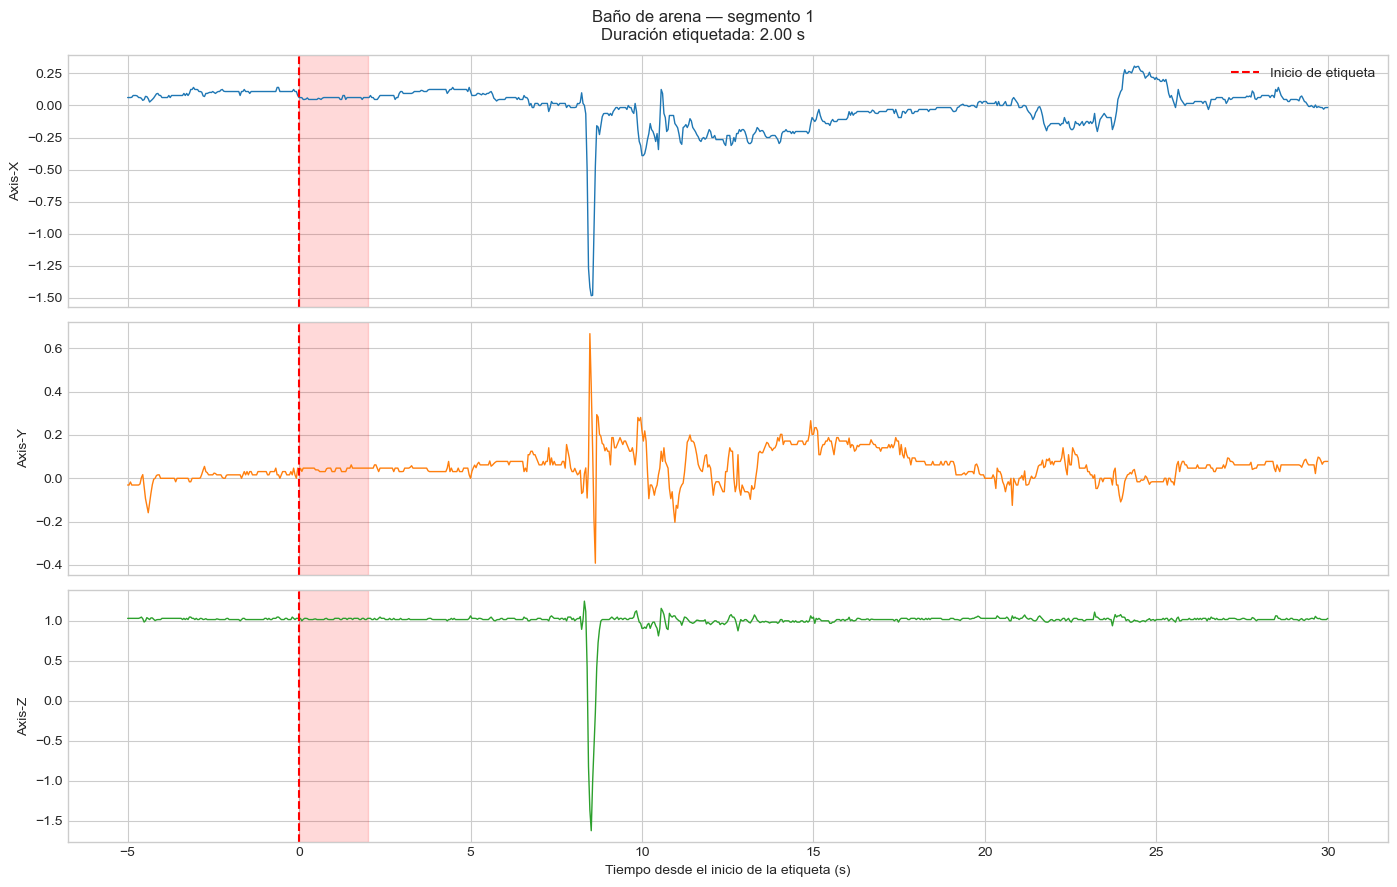

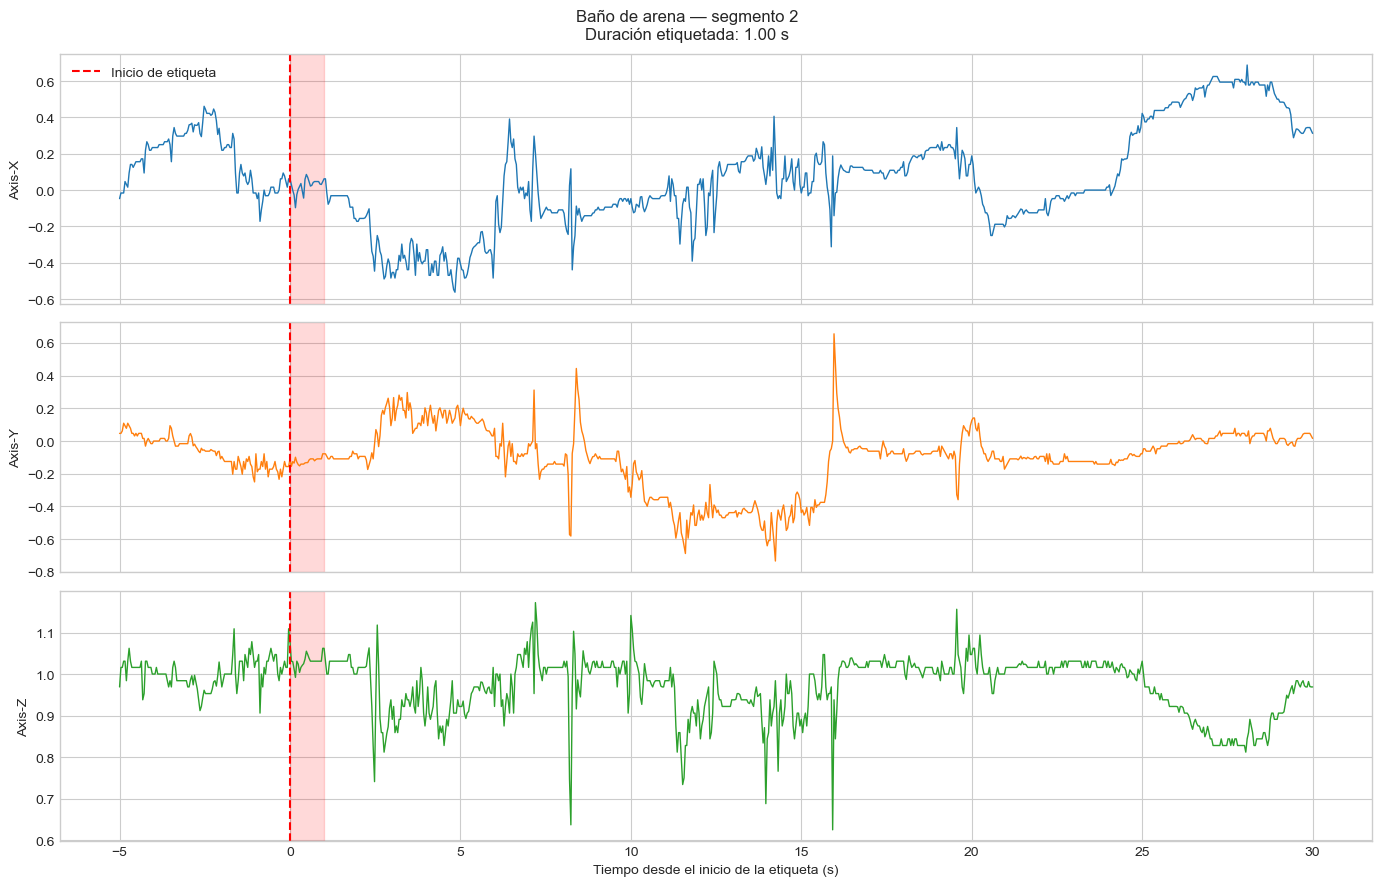

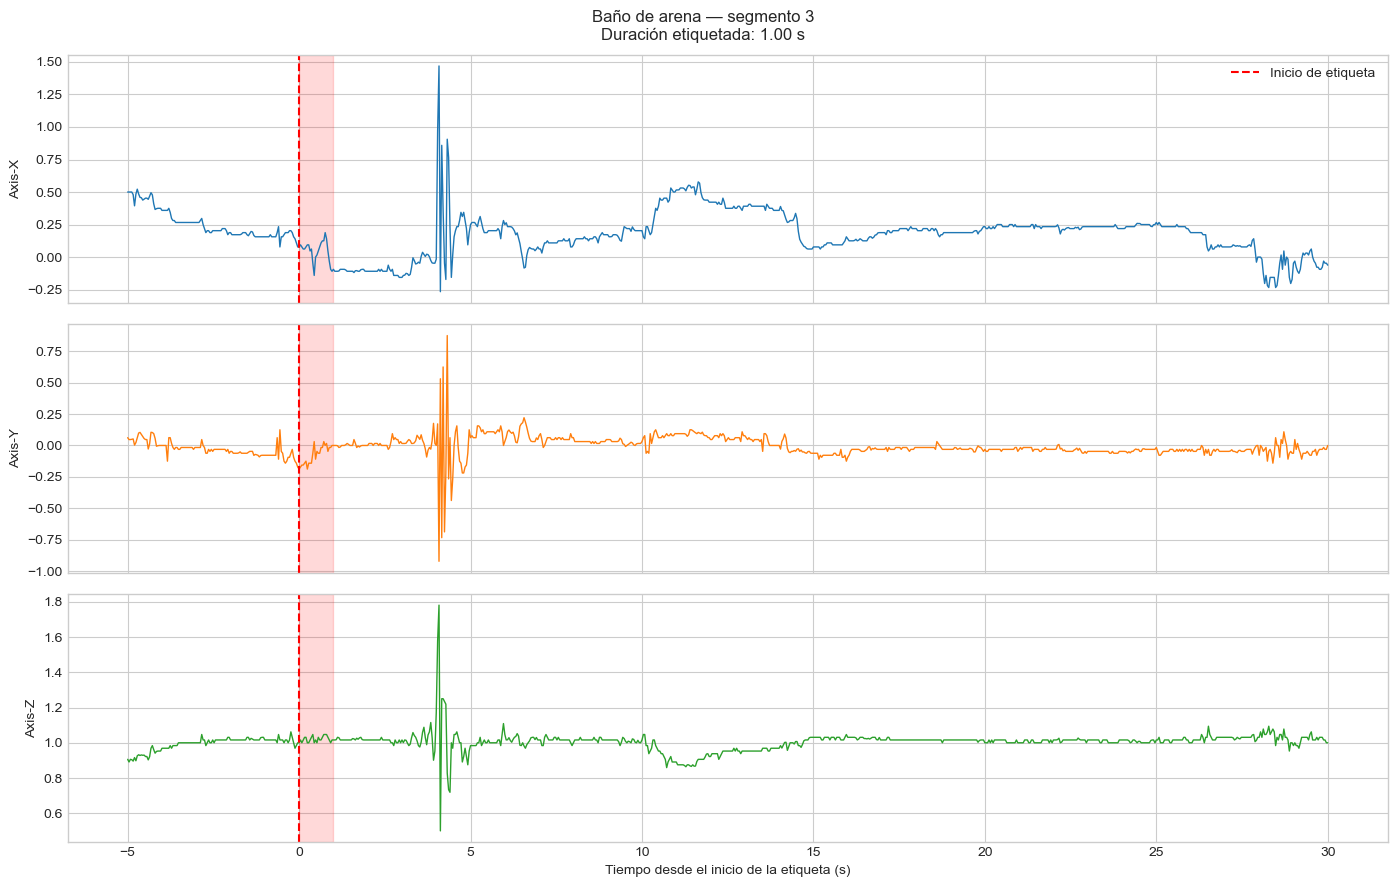

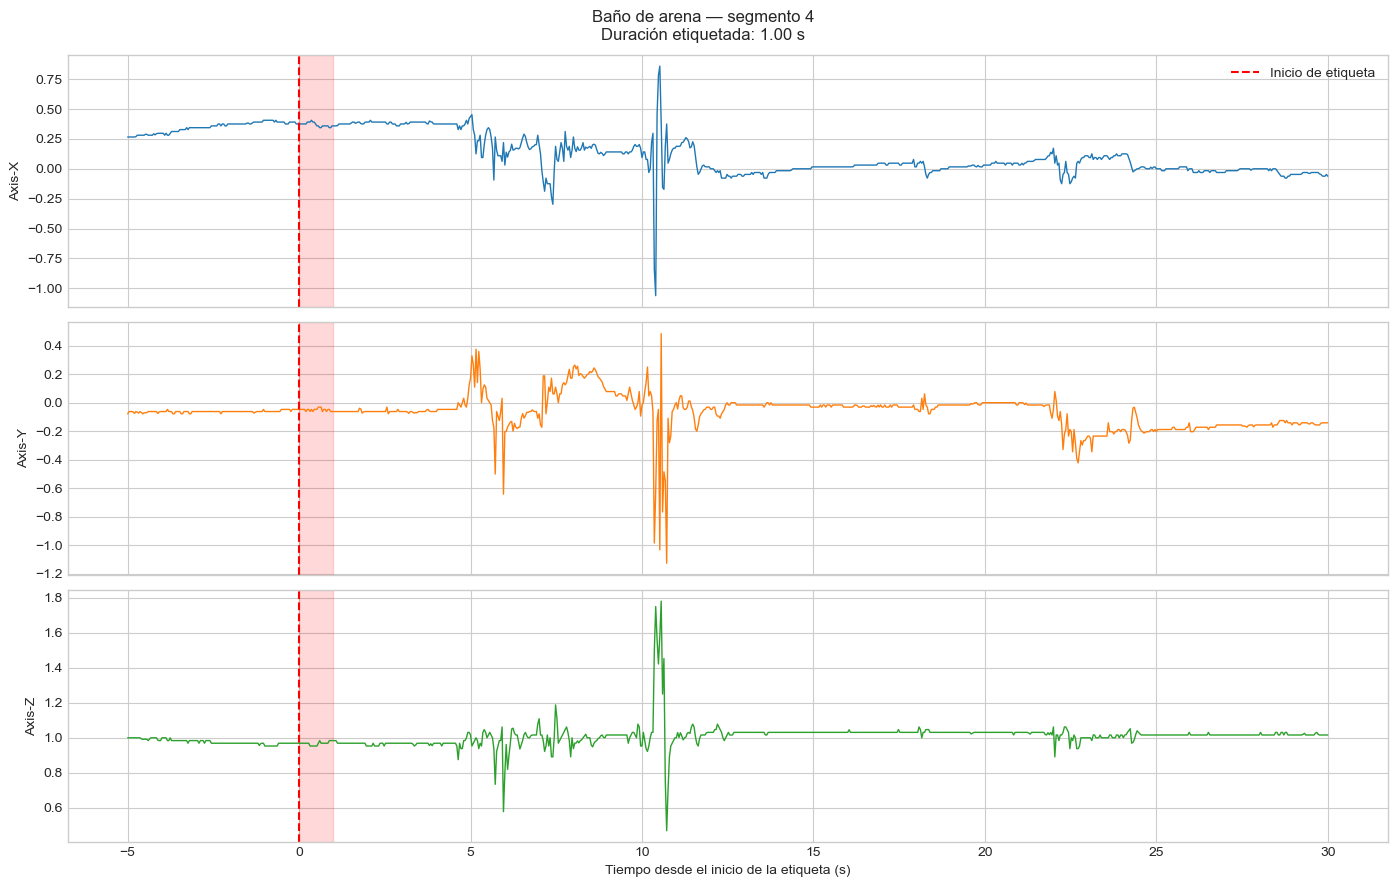

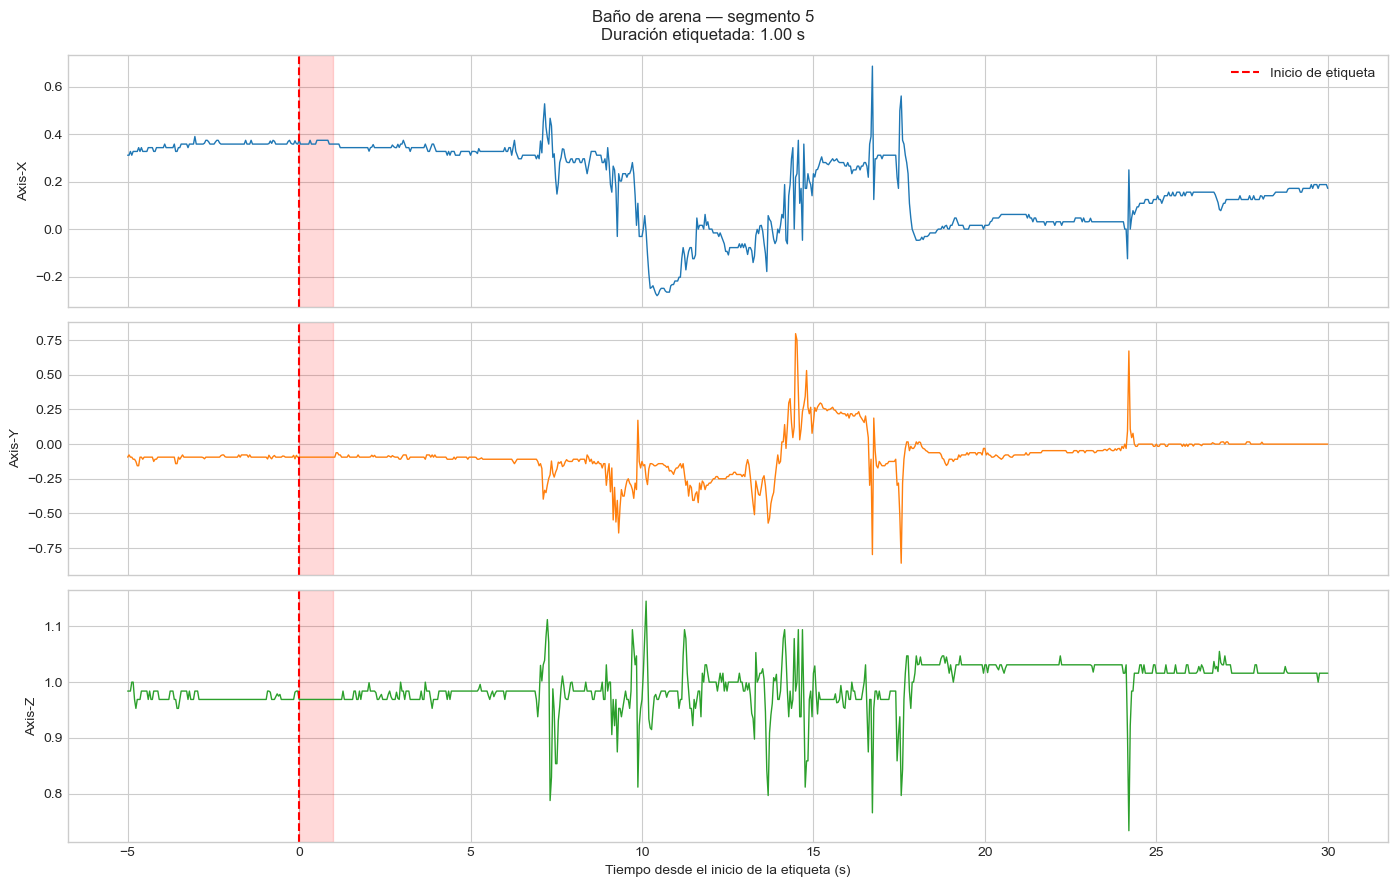

In [20]:
for numero in range(
    min(5, len(segmentos_bano_ordenados))
):
    graficar_evento(
        datos_t02,
        segmentos_bano_ordenados,
        numero=numero,
        segundos_antes=5,
        segundos_despues=30
    )

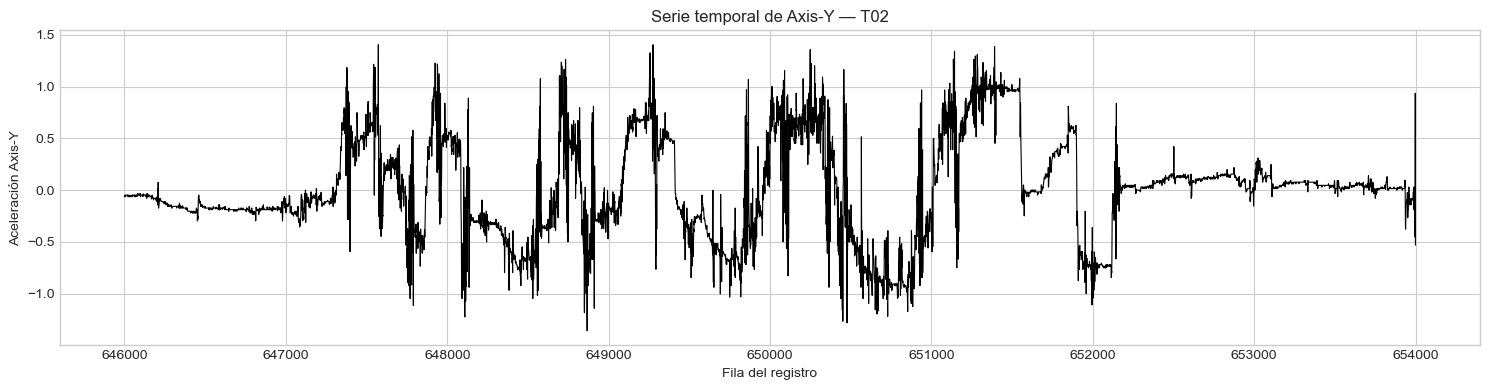

In [22]:
serie = acelerometria_t02.iloc[646000:654000]

plt.figure(figsize=(15, 4))
plt.plot(serie["Axis-Y"], color="black", linewidth=0.8)
plt.xlabel("Fila del registro")
plt.ylabel("Aceleración Axis-Y")
plt.title("Serie temporal de Axis-Y — T02")
plt.tight_layout()
plt.show()

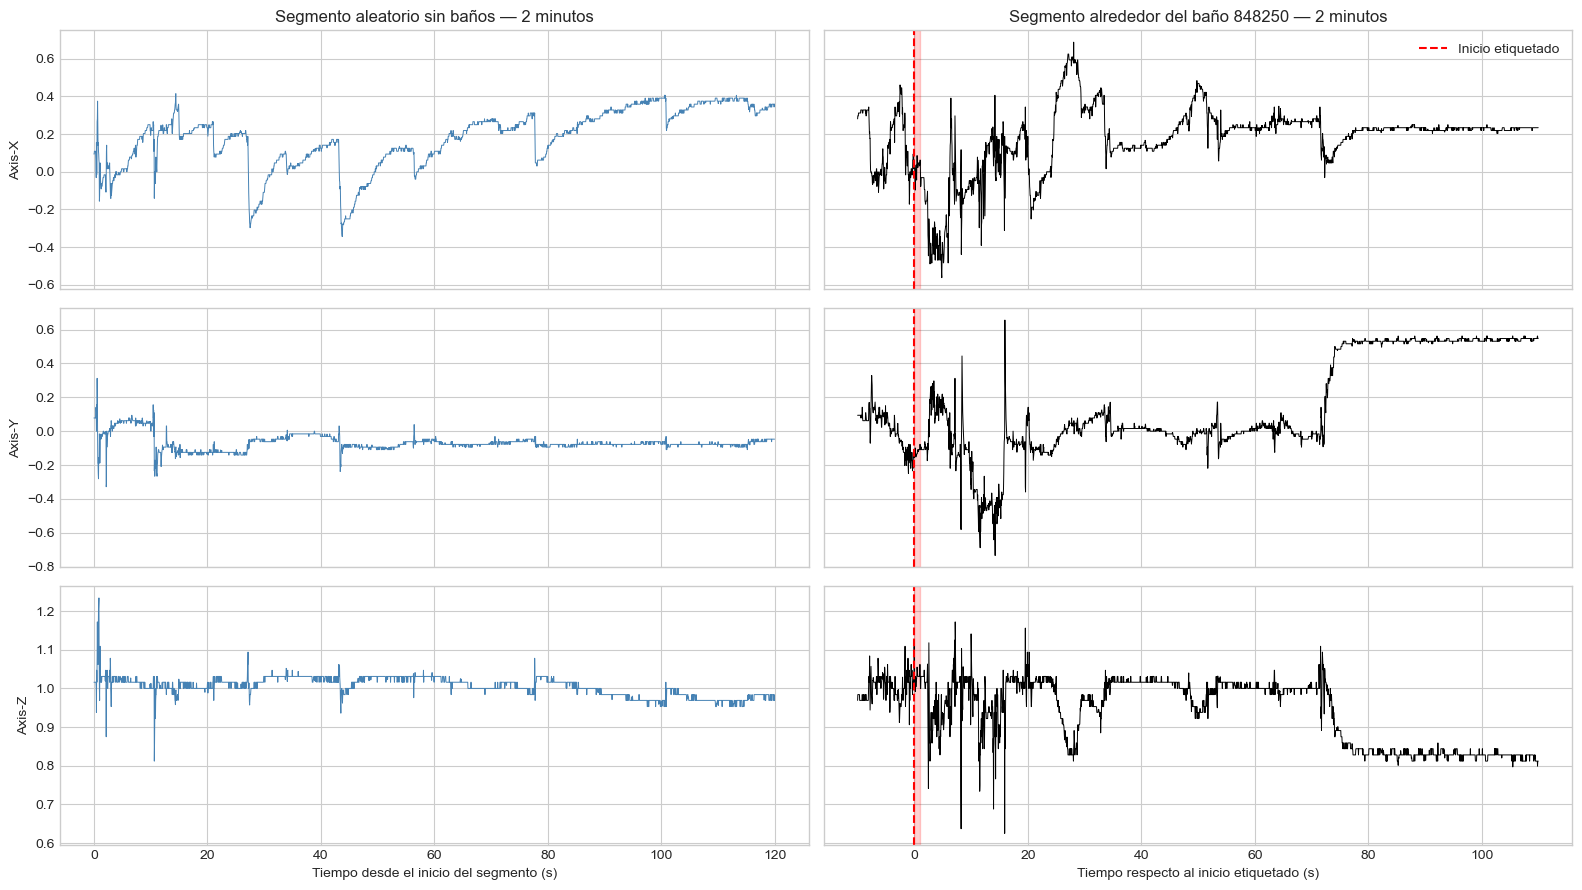

In [23]:
import numpy as np
import matplotlib.pyplot as plt

FS = 25
duracion_segundos = 120
n_muestras = duracion_segundos * FS

# Semilla para poder reproducir la selección aleatoria
rng = np.random.default_rng(42)

# --------------------------------------------------
# 1. Buscar un intervalo aleatorio sin baños etiquetados
# --------------------------------------------------

for intento in range(1000):

    posicion_inicial = rng.integers(
        0,
        len(datos_t02) - n_muestras
    )

    segmento_random = datos_t02.iloc[
        posicion_inicial : posicion_inicial + n_muestras
    ].copy()

    # Comprobar que no haya baños etiquetados
    sin_bano = segmento_random["Baño de arena"].sum() == 0

    # Comprobar que los sample_id sean consecutivos
    indices_consecutivos = (
        np.diff(segmento_random.index.to_numpy()) == 1
    ).all()

    if sin_bano and indices_consecutivos:
        break

else:
    raise RuntimeError(
        "No se encontró un intervalo continuo sin baños."
    )

# Tiempo relativo del segmento aleatorio
tiempo_random = np.arange(len(segmento_random)) / FS


# --------------------------------------------------
# 2. Elegir aleatoriamente un baño etiquetado
# --------------------------------------------------

es_bano = datos_t02["Baño de arena"].eq(1)

# Una etiqueta es inicio si la muestra anterior no era baño
inicios_bano = datos_t02.index[
    es_bano & ~es_bano.shift(fill_value=False)
]

inicio_bano = rng.choice(inicios_bano)

# Posición del comienzo del baño dentro del DataFrame
posicion_bano = datos_t02.index.get_loc(inicio_bano)

# Comenzar 10 segundos antes del baño
posicion_inicial_bano = max(
    0,
    posicion_bano - 10 * FS
)

posicion_final_bano = (
    posicion_inicial_bano + n_muestras
)

segmento_bano = datos_t02.iloc[
    posicion_inicial_bano : posicion_final_bano
].copy()

# Tiempo relativo al inicio de la etiqueta
tiempo_bano = (
    segmento_bano.index.to_numpy() - inicio_bano
) / FS

mascara_bano = (
    segmento_bano["Baño de arena"].to_numpy() == 1
)


# --------------------------------------------------
# 3. Graficar la comparación
# --------------------------------------------------

ejes = ["Axis-X", "Axis-Y", "Axis-Z"]

fig, ax = plt.subplots(
    3,
    2,
    figsize=(16, 9),
    sharex="col",
    sharey="row"
)

for fila, eje in enumerate(ejes):

    # Segmento aleatorio
    ax[fila, 0].plot(
        tiempo_random,
        segmento_random[eje],
        color="steelblue",
        linewidth=0.7
    )

    ax[fila, 0].set_ylabel(eje)

    # Segmento asociado a un baño
    ax[fila, 1].plot(
        tiempo_bano,
        segmento_bano[eje],
        color="black",
        linewidth=0.7
    )

    # Inicio de la etiqueta
    ax[fila, 1].axvline(
        0,
        color="red",
        linestyle="--",
        linewidth=1.5,
        label="Inicio etiquetado"
    )

    # Región etiquetada como baño
    ax[fila, 1].fill_between(
        tiempo_bano,
        0,
        1,
        where=mascara_bano,
        transform=ax[fila, 1].get_xaxis_transform(),
        color="red",
        alpha=0.18
    )

ax[0, 0].set_title(
    "Segmento aleatorio sin baños — 2 minutos"
)

ax[0, 1].set_title(
    f"Segmento alrededor del baño {inicio_bano} — 2 minutos"
)

ax[2, 0].set_xlabel("Tiempo desde el inicio del segmento (s)")
ax[2, 1].set_xlabel("Tiempo respecto al inicio etiquetado (s)")

ax[0, 1].legend()

plt.tight_layout()
plt.show()

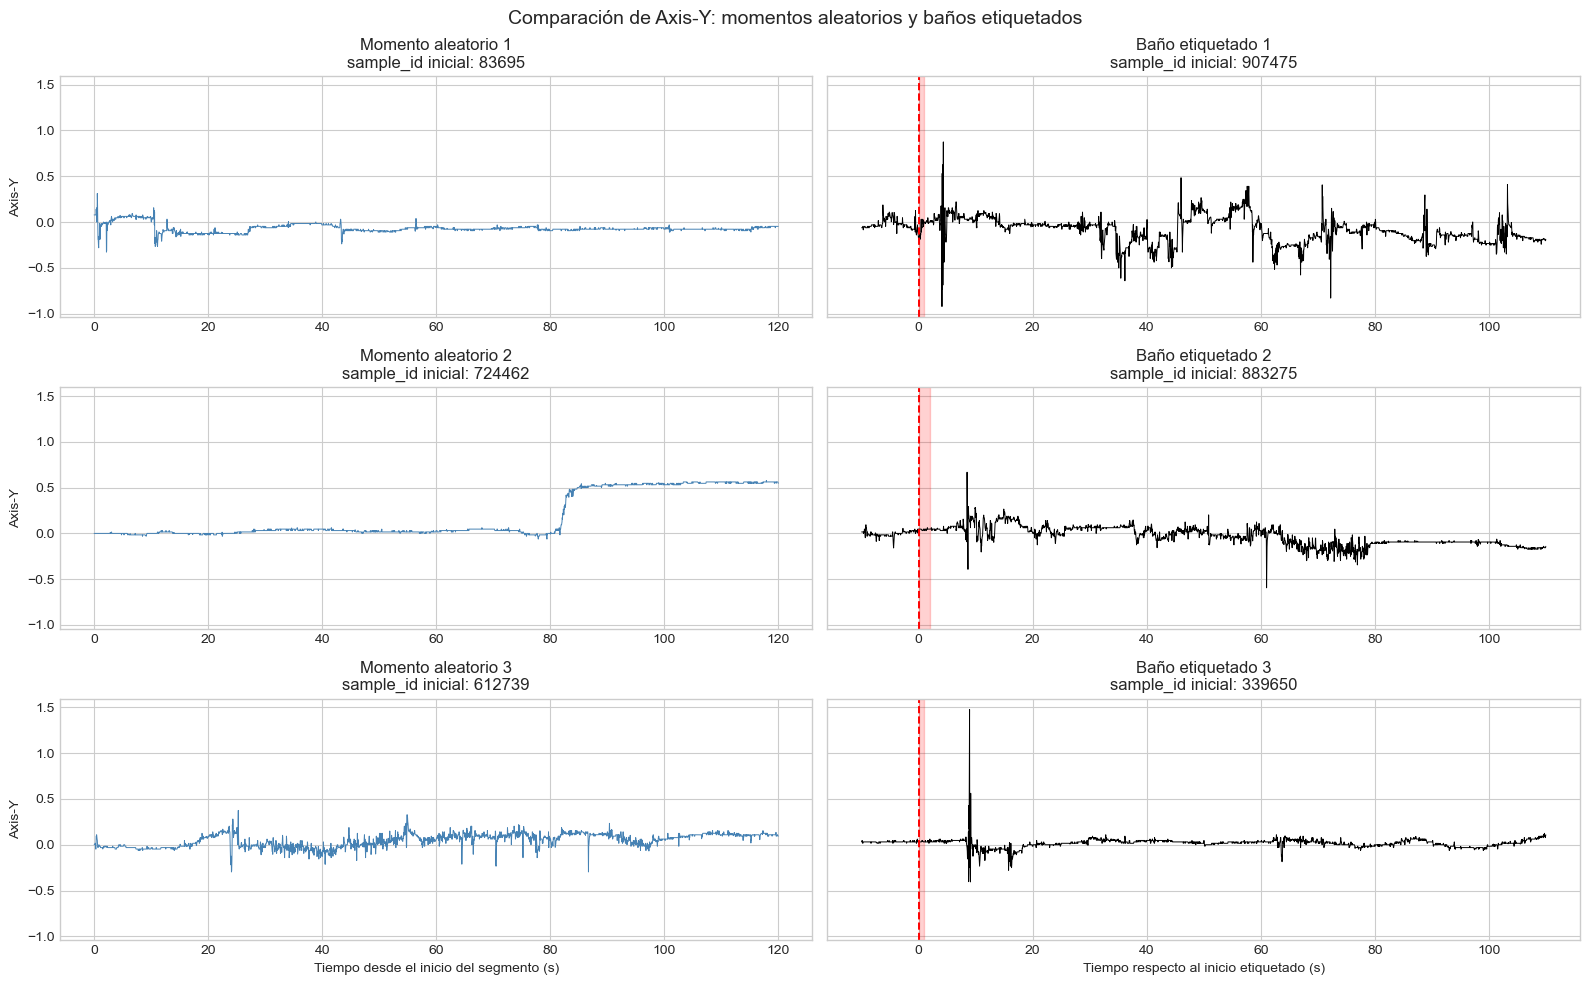

In [24]:
import numpy as np
import matplotlib.pyplot as plt

FS = 25
duracion_segundos = 120
n_muestras = duracion_segundos * FS

rng = np.random.default_rng(42)

# ==================================================
# 1. Seleccionar tres segmentos aleatorios sin baños
# ==================================================

segmentos_random = []
posiciones_elegidas = []

for intento in range(5000):

    posicion = rng.integers(
        0,
        len(datos_t02) - n_muestras
    )

    segmento = datos_t02.iloc[
        posicion : posicion + n_muestras
    ].copy()

    sin_bano = segmento["Baño de arena"].sum() == 0

    indices_consecutivos = (
        np.diff(segmento.index.to_numpy()) == 1
    ).all()

    # Evitar que los segmentos aleatorios se superpongan
    sin_superposicion = all(
        abs(posicion - anterior) >= n_muestras
        for anterior in posiciones_elegidas
    )

    if sin_bano and indices_consecutivos and sin_superposicion:
        segmentos_random.append(segmento)
        posiciones_elegidas.append(posicion)

    if len(segmentos_random) == 3:
        break

if len(segmentos_random) < 3:
    raise RuntimeError(
        "No se pudieron encontrar tres segmentos adecuados."
    )


# ==================================================
# 2. Identificar y seleccionar tres baños
# ==================================================

es_bano = datos_t02["Baño de arena"].eq(1)

# El inicio ocurre cuando la muestra actual es baño
# y la muestra anterior no lo era
inicios_bano = datos_t02.index[
    es_bano & ~es_bano.shift(fill_value=False)
].to_numpy()

inicios_seleccionados = rng.choice(
    inicios_bano,
    size=3,
    replace=False
)

segmentos_bano = []

for inicio_bano in inicios_seleccionados:

    posicion_bano = datos_t02.index.get_loc(inicio_bano)

    # Mostrar 10 segundos antes y 110 segundos después
    posicion_inicial = max(
        0,
        posicion_bano - 10 * FS
    )

    posicion_final = posicion_inicial + n_muestras

    segmento = datos_t02.iloc[
        posicion_inicial : posicion_final
    ].copy()

    segmentos_bano.append(
        (inicio_bano, segmento)
    )


# ==================================================
# 3. Graficar las comparaciones
# ==================================================

fig, ax = plt.subplots(
    3,
    2,
    figsize=(16, 10),
    sharey=True
)

for fila in range(3):

    # ----------------------------------------------
    # Segmento aleatorio
    # ----------------------------------------------

    segmento_random = segmentos_random[fila]

    tiempo_random = (
        np.arange(len(segmento_random)) / FS
    )

    ax[fila, 0].plot(
        tiempo_random,
        segmento_random["Axis-Y"],
        color="steelblue",
        linewidth=0.7
    )

    ax[fila, 0].set_title(
        "Momento aleatorio "
        f"{fila + 1}\n"
        f"sample_id inicial: {segmento_random.index[0]}"
    )

    ax[fila, 0].set_ylabel("Axis-Y")


    # ----------------------------------------------
    # Segmento correspondiente a un baño
    # ----------------------------------------------

    inicio_bano, segmento_bano = segmentos_bano[fila]

    tiempo_bano = (
        segmento_bano.index.to_numpy() - inicio_bano
    ) / FS

    mascara_bano = (
        segmento_bano["Baño de arena"].to_numpy() == 1
    )

    ax[fila, 1].plot(
        tiempo_bano,
        segmento_bano["Axis-Y"],
        color="black",
        linewidth=0.7
    )

    # Inicio de la etiqueta
    ax[fila, 1].axvline(
        0,
        color="red",
        linestyle="--",
        linewidth=1.4
    )

    # Muestras etiquetadas como baño
    ax[fila, 1].fill_between(
        tiempo_bano,
        0,
        1,
        where=mascara_bano,
        transform=ax[fila, 1].get_xaxis_transform(),
        color="red",
        alpha=0.18
    )

    ax[fila, 1].set_title(
        "Baño etiquetado "
        f"{fila + 1}\n"
        f"sample_id inicial: {inicio_bano}"
    )


ax[2, 0].set_xlabel(
    "Tiempo desde el inicio del segmento (s)"
)

ax[2, 1].set_xlabel(
    "Tiempo respecto al inicio etiquetado (s)"
)

fig.suptitle(
    "Comparación de Axis-Y: momentos aleatorios y baños etiquetados",
    fontsize=14
)

plt.tight_layout()
plt.show()